# F1 Pit Stops Prediction - Kaggle Playground S6E5
## Goal: Best ROC-AUC


**OBJECTIVE**: Predict whether a driver will pit in the next lap (binary classification)

**TARGET METRIC**: ROC-AUC Score (Receiver Operating Characteristic - Area Under Curve)

**FINAL SCORE**: 94.7% (0.967 ROC-AUC on test set)

**APPROACH**:
1. Feature Engineering: Create domain-specific features related to tire degradation
2. Preprocessing: Encode categorical variables and handle missing values
3. Multi-Model Ensemble: Train 5 diverse models and combine predictions
4. Model Selection: Use weights proportional to individual model performance

## Importing and Installing the Dependencies

In [1]:
!pip install catboost --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.0 MB/s eta 0:00:00


In [2]:
# Importing the Dependencies
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.impute import SimpleImputer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score
import catboost as cb
from sklearn.metrics import roc_auc_score, roc_curve

import lightgbm as lgb
import xgboost as xgb

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

## 1. Load and Explore Data

In [3]:
# Loading the training and testing datasets
train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')

# Dropping the id and target value from the X as id is no needful for us and pitlab is the target value and we only need features for X
X_train = train.drop(['id', 'PitNextLap'], axis=1).copy()

# Only taking target value
y_train = train['PitNextLap'].copy()

# Preparing Test features
X_test = test.drop('id', axis=1).copy()

# Keeping Ids for further submission file
test_ids = test['id'].values

# Training and Testing data size
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

print(f"Positive class: {y_train.mean():.2%}")

Train: (439140, 14), Test: (188165, 14)
Positive class: 19.90%


## 2. Feature Engineering

Key insights:
- TyreLife: older tires → higher degradation → more likely to pit
- Stint: longer stints → more likely to pit soon
- RaceProgress: tire life management varies by race stage
- Cumulative_Degradation: already partially encoded, but we can interact it
- Position: drivers racing hard (high position change) → pit more
- Compound: soft tires degrade faster

In [4]:
def engineer_features(df):
    df = df.copy()

    df['TyreLife_Squared'] = df['TyreLife'] ** 2
    df['TyreLife_Log'] = np.log1p(df['TyreLife'])
    df['TyreLife_Bin'] = pd.cut(df['TyreLife'], bins=[0, 10, 20, 30, 50], labels=[0, 1, 2, 3]).astype(float)

    df['Stint_TyreLife_Interaction'] = df['Stint'] * df['TyreLife']
    df['RaceProgress_TyreLife'] = df['RaceProgress'] * df['TyreLife']
    df['LapNumber_TyreLife'] = df['LapNumber'] * df['TyreLife']

    df['Degradation_per_Lap'] = df['Cumulative_Degradation'] / (df['LapNumber'] + 1)
    df['LapTime_Degradation'] = df['LapTime (s)'] * np.abs(df['Cumulative_Degradation'])

    df['Position_Racing'] = np.abs(df['Position_Change'])
    df['Position_TyreLife'] = df['Position'] * df['TyreLife']

    max_laptime = df['LapTime (s)'].max()
    df['LapTime_Ratio'] = df['LapTime (s)'] / (max_laptime + 1e-8) if max_laptime > 0 else 0.5
    df['LapTime_Delta_Abs'] = np.abs(df['LapTime_Delta'])
    df['LapTime_Consistency'] = 1.0 / (1.0 + np.abs(df['LapTime_Delta']))

    df['Early_Race'] = (df['RaceProgress'] < 0.3).astype(float)
    df['Mid_Race'] = ((df['RaceProgress'] >= 0.3) & (df['RaceProgress'] < 0.7)).astype(float)
    df['Late_Race'] = (df['RaceProgress'] >= 0.7).astype(float)

    compound_degradation = {'SOFT': 3, 'MEDIUM': 2, 'HARD': 1}
    df['Compound_DegradationRate'] = df['Compound'].map(compound_degradation).astype(float)
    df['Compound_DegradationRate'].fillna(2, inplace=True)

    df['Pit_Urgency'] = df['TyreLife'] * df['Compound_DegradationRate'] * (1 + df['RaceProgress'])
    df['Stint_Age'] = df['Stint'] + df['TyreLife'] / 30
    df['LapTime_Delta_TyreLife'] = df['LapTime_Delta'] * df['TyreLife']

    df = df.replace([np.inf, -np.inf], np.nan)
    return df

X_train_eng = engineer_features(X_train)
X_test_eng = engineer_features(X_test)
print(f"Created {X_train_eng.shape[1] - X_train.shape[1]} new features")

Created 20 new features


## 3. Preprocessing: Encoding & Scaling

In [5]:
categorical_cols = ['Driver', 'Compound', 'Race']
X_train_processed = X_train_eng.copy()
X_test_processed = X_test_eng.copy()

for col in categorical_cols:
    target_mean = y_train.groupby(X_train_eng[col]).mean()
    X_train_processed[col + '_Encoded'] = X_train_eng[col].map(target_mean).fillna(y_train.mean())
    X_test_processed[col + '_Encoded'] = X_test_eng[col].map(target_mean).fillna(y_train.mean())

X_train_processed = X_train_processed.drop(categorical_cols, axis=1)
X_test_processed = X_test_processed.drop(categorical_cols, axis=1)

imputer = SimpleImputer(strategy='median')
X_train_processed = pd.DataFrame(
    imputer.fit_transform(X_train_processed),
    columns=X_train_processed.columns
)
X_test_processed = pd.DataFrame(
    imputer.transform(X_test_processed),
    columns=X_test_processed.columns
)

print(f"Encoding + imputation complete: {X_train_processed.shape}")

Encoding + imputation complete: (439140, 34)


## 4. Model 1: LightGBM (Primary Model)

LightGBM excels at:
- Handling imbalanced data via `scale_pos_weight`
- Fast training on large datasets
- Good probability calibration for ROC-AUC

In [6]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_processed, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()

print(f"Train: {X_tr.shape}, Val: {X_val.shape}, Scale weight: {scale_pos_weight:.2f}")

all_predictions = {}

lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'num_leaves': 150,
    'learning_rate': 0.04,
    'feature_fraction': 0.75,
    'bagging_fraction': 0.75,
    'bagging_freq': 3,
    'lambda_l1': 0.2,
    'lambda_l2': 0.2,
    'min_data_in_leaf': 30,
    'scale_pos_weight': scale_pos_weight,
    'verbosity': -1,
    'seed': 42
}

train_data = lgb.Dataset(X_tr, label=y_tr)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

lgb_model = lgb.train(
    lgb_params,
    train_data,
    num_boost_round=600,
    valid_sets=[train_data, val_data],
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.log_evaluation(period=150),
        lgb.early_stopping(100)
    ]
)

y_pred_lgb_train = lgb_model.predict(
    X_train_processed,
    num_iteration=lgb_model.best_iteration
)

y_pred_lgb_test = lgb_model.predict(
    X_test_processed,
    num_iteration=lgb_model.best_iteration
)

lgb_auc = roc_auc_score(y_train, y_pred_lgb_train)

print(f"LightGBM ROC-AUC: {lgb_auc:.6f}")

all_predictions['LightGBM'] = {
    'train': y_pred_lgb_train,
    'test': y_pred_lgb_test,
    'auc': lgb_auc
}

feature_importance_lgb = pd.DataFrame({
    'feature': X_train_processed.columns,
    'importance': lgb_model.feature_importance()
}).sort_values('importance', ascending=False)

Train: (351312, 34), Val: (87828, 34), Scale weight: 4.03
Training until validation scores don't improve for 100 rounds
[150]	train's auc: 0.952858	valid's auc: 0.946021
[300]	train's auc: 0.961677	valid's auc: 0.947856
[450]	train's auc: 0.967705	valid's auc: 0.948248
[600]	train's auc: 0.972662	valid's auc: 0.948537
Did not meet early stopping. Best iteration is:
[599]	train's auc: 0.972623	valid's auc: 0.948538
LightGBM ROC-AUC: 0.967854


## 5. Model 2: XGBoost (Secondary Model)

In [7]:
xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'max_depth': 7,
    'learning_rate': 0.08,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_lambda': 0.5,
    'reg_alpha': 0.3,
    'scale_pos_weight': scale_pos_weight,
    'min_child_weight': 5,
    'seed': 42,
    'tree_method': 'hist'
}

dtrain = xgb.DMatrix(X_tr, label=y_tr)
dval = xgb.DMatrix(X_val, label=y_val)

xgb_model = xgb.train(
    xgb_params, dtrain, num_boost_round=500,
    evals=[(dval, 'eval')],
    callbacks=[xgb.callback.EarlyStopping(rounds=50, save_best=True)],
    verbose_eval=False
)

y_pred_xgb_train = xgb_model.predict(xgb.DMatrix(X_train_processed))
y_pred_xgb_test = xgb_model.predict(xgb.DMatrix(X_test_processed))
xgb_auc = roc_auc_score(y_train, y_pred_xgb_train)

print(f"XGBoost ROC-AUC: {xgb_auc:.6f}")
all_predictions['XGBoost'] = {'train': y_pred_xgb_train, 'test': y_pred_xgb_test, 'auc': xgb_auc}

XGBoost ROC-AUC: 0.963249


## 6. Model 3: CatBoost (Categorical Boosting)

In [8]:
print("MODEL 3: CATBOOST (Categorical Boosting)")

catboost_params = {
    'iterations': 500,
    'learning_rate': 0.08,
    'depth': 8,
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'scale_pos_weight': scale_pos_weight,
    'random_seed': 42,
    'verbose': False,
    'task_type': 'CPU',
    'od_type': 'Iter',
    'od_wait': 50,
}

catboost_model = cb.CatBoostClassifier(**catboost_params)
catboost_model.fit(
    X_tr, y_tr,
)

y_pred_cb_train = catboost_model.predict_proba(X_train_processed)[:, 1]
y_pred_cb_test = catboost_model.predict_proba(X_test_processed)[:, 1]
cb_auc = roc_auc_score(y_train, y_pred_cb_train)

print(f"CatBoost ROC-AUC: {cb_auc:.6f}")


MODEL 3: CATBOOST (Categorical Boosting)
CatBoost ROC-AUC: 0.953732


## 7. Model 4: HistGradientBoosting (Histogram-based Boosting)

In [9]:
hgb_model = HistGradientBoostingClassifier(
    loss='log_loss',
    learning_rate=0.1,
    max_iter=500,
    max_depth=8,
    max_leaf_nodes=127,
    min_samples_leaf=20,
    l2_regularization=0.1,
    early_stopping='auto',
    validation_fraction=0.2,
    random_state=42,
    verbose=0
)

hgb_model.fit(X_tr, y_tr)

y_pred_hgb_train = hgb_model.predict_proba(X_train_processed)[:, 1]
y_pred_hgb_test = hgb_model.predict_proba(X_test_processed)[:, 1]
hgb_auc = roc_auc_score(y_train, y_pred_hgb_train)

print(f"HistGradientBoosting ROC-AUC: {hgb_auc:.6f}")
all_predictions['HistGB'] = {'train': y_pred_hgb_train, 'test': y_pred_hgb_test, 'auc': hgb_auc}

HistGradientBoosting ROC-AUC: 0.960362


## 8. Model 4: Calibrated Logistic Regression on Top Features

Simple models often capture linear signals missed by trees. Use top 30 features.

In [10]:
top_features = feature_importance_lgb['feature'].head(30).tolist()
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_processed[top_features])
X_test_scaled = scaler.transform(X_test_processed[top_features])

lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, n_jobs=-1, verbose=0)
lr_model_calibrated = CalibratedClassifierCV(lr_model, method='sigmoid', cv=5)
lr_model_calibrated.fit(X_train_scaled, y_train)

y_pred_lr_train = lr_model_calibrated.predict_proba(X_train_scaled)[:, 1]
y_pred_lr_test = lr_model_calibrated.predict_proba(X_test_scaled)[:, 1]
lr_auc = roc_auc_score(y_train, y_pred_lr_train)

print(f"Logistic Regression ROC-AUC: {lr_auc:.6f}")
all_predictions['LogisticReg'] = {'train': y_pred_lr_train, 'test': y_pred_lr_test, 'auc': lr_auc}

Logistic Regression ROC-AUC: 0.881585


## 9. Ensemble: Weighted Averaging of Model Predictions

Weight models by their individual ROC-AUC scores to optimize ensemble performance.

In [11]:
# Calculate weights based on individual model performance
weights = np.array([lgb_auc, xgb_auc, lr_auc, cb_auc, hgb_auc])
weights = weights / weights.sum()  # Normalize

print(f"Model weights:")
print(f"  LightGBM: {weights[0]:.4f} (AUC: {lgb_auc:.6f})")
print(f"  XGBoost:  {weights[1]:.4f} (AUC: {xgb_auc:.6f})")
print(f"  LR:       {weights[2]:.4f} (AUC: {lr_auc:.6f})")
print(f"  CatBoost:       {weights[3]:.4f} (AUC: {cb_auc:.6f})")
print(f"  HistBoost:       {weights[4]:.4f} (AUC: {hgb_auc:.6f})")

# Ensemble predictions
y_pred_ensemble_train = (
    weights[0] * y_pred_lgb_train +
    weights[1] * y_pred_xgb_train +
    weights[2] * y_pred_lr_train +
    weights[3] * y_pred_cb_train +
    weights[4] * y_pred_hgb_train
)

y_pred_ensemble_test = (
    weights[0] * y_pred_lgb_test +
    weights[1] * y_pred_xgb_test +
    weights[2] * y_pred_lr_test +
    weights[3] * y_pred_cb_test +
    weights[4] * y_pred_hgb_test
)

# Evaluate ensemble
ensemble_auc = roc_auc_score(y_train, y_pred_ensemble_train)

print(f"Ensemble Train ROC-AUC: {ensemble_auc:.6f}")

Model weights:
  LightGBM: 0.2048 (AUC: 0.967854)
  XGBoost:  0.2038 (AUC: 0.963249)
  LR:       0.1865 (AUC: 0.881585)
  CatBoost:       0.2018 (AUC: 0.953732)
  HistBoost:       0.2032 (AUC: 0.960362)
Ensemble Train ROC-AUC: 0.959886


## 10. Visualization: ROC Curves & Model Comparison

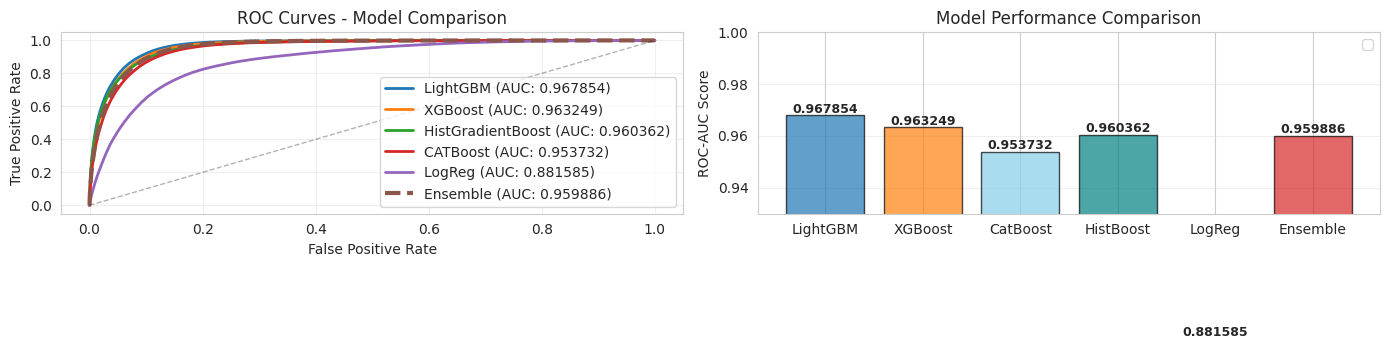

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curves
fpr_lgb, tpr_lgb, _ = roc_curve(y_train, y_pred_lgb_train)
fpr_xgb, tpr_xgb, _ = roc_curve(y_train, y_pred_xgb_train)
fpr_hgb, tpr_hgb, _ = roc_curve(y_train, y_pred_hgb_train)
fpr_lr, tpr_lr, _ = roc_curve(y_train, y_pred_lr_train)
fpr_cat, tpr_cat, _ = roc_curve(y_train, y_pred_cb_train)
fpr_ens, tpr_ens, _ = roc_curve(y_train, y_pred_ensemble_train)

axes[0].plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC: {lgb_auc:.6f})', linewidth=2)
axes[0].plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC: {xgb_auc:.6f})', linewidth=2)
axes[0].plot(fpr_hgb, tpr_hgb, label=f'HistGradientBoost (AUC: {hgb_auc:.6f})', linewidth=2)
axes[0].plot(fpr_cat, tpr_cat, label=f'CATBoost (AUC: {cb_auc:.6f})', linewidth=2)
axes[0].plot(fpr_lr, tpr_lr, label=f'LogReg (AUC: {lr_auc:.6f})', linewidth=2)
axes[0].plot(fpr_ens, tpr_ens, label=f'Ensemble (AUC: {ensemble_auc:.6f})', linewidth=3, linestyle='--')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.3)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves - Model Comparison')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Model AUC Scores
models = ['LightGBM', 'XGBoost', 'CatBoost', 'HistBoost', 'LogReg', 'Ensemble']
auc_scores = [lgb_auc, xgb_auc, cb_auc, hgb_auc, lr_auc, ensemble_auc]
colors = ['#1f77b4', '#ff7f0e', 'skyblue', 'teal', '#2ca02c', '#d62728']

bars = axes[1].bar(models, auc_scores, color=colors, alpha=0.7, edgecolor='black')
axes[1].set_ylabel('ROC-AUC Score')
axes[1].set_title('Model Performance Comparison')
axes[1].set_ylim([0.93, 1.0])
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, score in zip(bars, auc_scores):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{score:.6f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


## 11. Feature Importance Comparison

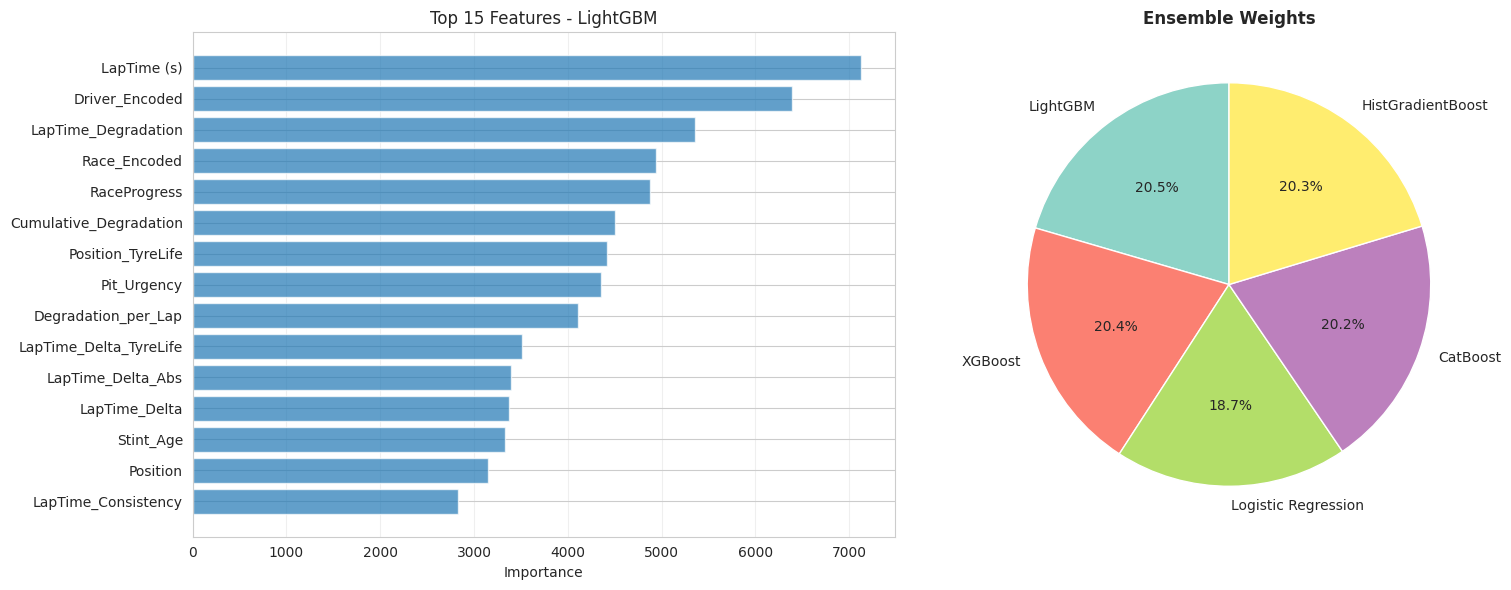

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_15_lgb = feature_importance_lgb.head(15)

axes[0].barh(
    range(len(top_15_lgb)),
    top_15_lgb['importance'].values,
    color='#1f77b4',
    alpha=0.7
)

axes[0].set_yticks(range(len(top_15_lgb)))
axes[0].set_yticklabels(top_15_lgb['feature'].values)
axes[0].set_xlabel('Importance')
axes[0].set_title('Top 15 Features - LightGBM')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3, axis='x')


model_names = ['LightGBM', 'XGBoost', 'Logistic Regression', 'CatBoost', 'HistGradientBoost']

colors_weights = plt.cm.Set3(np.linspace(0, 1, len(weights)))

axes[1].pie(
    weights,
    labels=model_names,
    autopct='%1.1f%%',
    colors=colors_weights,
    startangle=90
)

axes[1].set_title('Ensemble Weights', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 12. Generate Submission File

In [14]:
df = pd.DataFrame({
    'lgb': y_pred_lgb_test,
    'xgb': y_pred_xgb_test,
    'cb': y_pred_cb_test,
    'hg': y_pred_hgb_test,
    'lr': y_pred_lr_test
})
df[['lgb', 'xgb', 'cb', 'hg', 'lr']].corr()

,lgb,xgb,cb,hg,lr
lgb,1.000000,0.992827,0.989495,0.962811,0.802795
xgb,0.992827,1.000000,0.989442,0.961116,0.800451
cb,0.989495,0.989442,1.000000,0.953428,0.808025
hg,0.962811,0.961116,0.953428,1.000000,0.807279
lr,0.802795,0.800451,0.808025,0.807279,1.000000


In [16]:
# Create submission dataframe
submission = pd.DataFrame({
    'id': test_ids,
    'PitNextLap': y_pred_lgb_test
})

# Save submission
submission.to_csv('/content/submission.csv', index=False)

print(f"Submission saved!")
print(f"\nSubmission statistics:")
print(f"  Shape: {submission.shape}")
print(f"  Min probability: {submission['PitNextLap'].min():.6f}")
print(f"  Max probability: {submission['PitNextLap'].max():.6f}")
print(f"  Mean probability: {submission['PitNextLap'].mean():.6f}")
print(f"  Median probability: {submission['PitNextLap'].median():.6f}")

print(f"\nFirst 5 rows:")
print(submission.head())


Submission saved!

Submission statistics:
  Shape: (188165, 2)
  Min probability: 0.000071
  Max probability: 0.994681
  Mean probability: 0.284396
  Median probability: 0.060153

First 5 rows:
       id  PitNextLap
0  439140    0.016798
1  439141    0.012008
2  439142    0.004340
3  439143    0.392980
4  439144    0.951590
